# Graph Analyze : clustering

```networkx``` documentation available [here](https://networkx.org/documentation/stable/reference/algorithms/index.html)

## 0 - Data Reading

In [1]:
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from typing import Tuple, List, Dict, Any

import networkx as nx
from networkx.algorithms.community import louvain_communities, modularity
from sklearn.metrics import adjusted_rand_score
from itertools import combinations

subset = "horoscope_full"
df = pd.read_csv(f'..\\data\\{subset}.csv')
df.head()

input = 0
# 0 for MinHashing matrix
# 1 for Frequent Itemsets matrix
# 2 for Random graph

## 1 - Graph Definition
### 
use of the ```networkx``` to generate a graph from the matrix of similarities

In [2]:
# -----------------------------------------
#  horoscope-extracted graph - MinHashing
# -----------------------------------------
def make_simmatrix_from_couples(
    df: pd.DataFrame,
    id1_col: str = "ID1",
    id2_col: str = "ID2",
    sim_col: str = "similarity",
    include_full_range: bool = True,
    dtype: Any = float
) -> Tuple[sparse.csr_matrix, List[Any], Dict[Any, int]]:
    """
    Build a symmetric similarity matrix from a dataframe of couples.

    Parameters
    ----------
    df : pd.DataFrame
        Columns: ID1, ID2, similarity (editable through parameters).
    include_full_range : bool
        If True and IDs are integer-like, fills missing IDs between min..max
        with zero rows/columns.
    dtype : numpy dtype
        Numeric type for matrix entries.

    Returns
    -------
    S : scipy.sparse.csr_matrix
        Symmetric similarity matrix.
    id_list : list
        Ordered list of IDs corresponding to rows/cols of S.
    id_to_index : dict
        Mapping ID -> matrix index.
    """

    # Validate columns
    if id1_col not in df.columns or id2_col not in df.columns or sim_col not in df.columns:
        raise ValueError(f"DataFrame must contain {id1_col}, {id2_col}, {sim_col}")

    # Gather IDs (ensure both are Index objects before append)
    ids = pd.Index(df[id1_col].dropna()).append(pd.Index(df[id2_col].dropna())).unique()

    # Detect integer-like IDs
    integer_like = False
    try:
        casted = np.array([int(x) for x in ids])
        integer_like = True
    except Exception:
        integer_like = False

    # Build ordered ID list
    if include_full_range and integer_like:
        min_id = int(casted.min())
        max_id = int(casted.max())
        id_list = list(range(min_id, max_id + 1))
    else:
        try:
            # Sort numerically if possible
            numeric_vals = np.array([float(x) for x in ids])
            order = np.argsort(numeric_vals)
            id_list = list(ids[order])
        except Exception:
            # Otherwise lexicographically
            id_list = sorted(ids, key=lambda x: str(x))

    # Map IDs to matrix indices
    id_to_index = {id_val: idx for idx, id_val in enumerate(id_list)}
    n = len(id_list)

    # Prepare COO data
    rows = []
    cols = []
    data = []

    for _, row in df.iterrows():
        a, b, val = row[id1_col], row[id2_col], row[sim_col]

        if pd.isna(a) or pd.isna(b) or pd.isna(val):
            continue
        if a not in id_to_index or b not in id_to_index:
            continue

        i, j = id_to_index[a], id_to_index[b]

        rows.append(i); cols.append(j); data.append(val)
        if i != j:
            rows.append(j); cols.append(i); data.append(val)

    # Build CSR matrix
    coo = sparse.coo_matrix((np.array(data, dtype=dtype),
                             (np.array(rows), np.array(cols))),
                            shape=(n, n))
    coo.sum_duplicates()
    S = coo.tocsr()

    return S, id_list, id_to_index

def generate_random_couples_df(
    n_ids: int,
    n_pairs: int,
    id_start: int = 0,
    sim_low: float = 0.0,
    sim_high: float = 1.0,
    seed: int = None
) -> pd.DataFrame:
    """
    Generate a random dataframe of the form:
        ID1, ID2, similarity

    Parameters
    ----------
    n_ids : int
        Number of distinct IDs to sample from.
    n_pairs : int
        Number of pairwise similarity rows to generate.
    id_start : int
        First ID index (default=0, IDs will be [id_start ... id_start+n_ids-1]).
    sim_low, sim_high : float
        Range of similarity values.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    df : pd.DataFrame
        DataFrame with shape (n_pairs, 3).
    """

    rng = np.random.default_rng(seed)

    ids = np.arange(id_start, id_start + n_ids)

    # Sample random pairs (allow duplicates)
    ID1 = rng.choice(ids, size=n_pairs, replace=True)
    ID2 = rng.choice(ids, size=n_pairs, replace=True)

    # Optionally avoid self-pairs (comment this out if you want them)
    mask = ID1 != ID2
    ID1 = ID1[mask]
    ID2 = ID2[mask]

    # Adjust length if needed
    n_final = len(ID1)

    sim = rng.uniform(sim_low, sim_high, size=n_final)

    df = pd.DataFrame({
        "ID1": ID1,
        "ID2": ID2,
        "similarity": sim
    })

    return df

if input == 0:
    # df_test = generate_random_couples_df(n_ids=50, n_pairs=200, seed=42)
    # print(df_test.head())
    ids_file_name = "similarity_general_lsh"
    df_minhash = pd.read_csv(f'..\\pre_results\\{ids_file_name}.csv')
    M_thr, id_list, id_to_index = make_simmatrix_from_couples(df_minhash)
    print(M_thr)

# -----------------------------------------
#  horoscope-extracted graph - Frequent Itemsets
# -----------------------------------------
if input == 1:
    freqitemsname = "shared_2_itemsets_matrix"
    mat_row = np.array(pd.read_csv(f"..\\pre_results\\{freqitemsname}.csv", sep=","))
    mat_row[:10,:10]

# -----------------------------------------
#              random graph
# -----------------------------------------

# Symmetric biased random matrix generator
def gen_matrix(N, max_val=10, lam=2.0, seed=42):
    """Generate an N x N symmetric integer matrix in [0, max_val] biased toward 0.

    Distribution: Poisson(lam) clipped to [0, max_val].
    Symmetry: Upper triangle sampled then mirrored.

    Args:
        N (int): Matrix dimension.
        max_val (int): Maximum (inclusive) value allowed.
        seed (int): RNG seed for reproducibility.
        lam (float): Lambda parameter for Poisson (smaller => more zeros).
    Returns:
        np.ndarray: Symmetric (N,N) integer matrix.
    """
    if N <= 0:
        raise ValueError("N must be positive.")
    rng = np.random.default_rng(seed)
    vals = rng.poisson(lam=lam, size=(N, N))
    vals = np.clip(vals, 0, max_val).astype(int)
    upper = np.triu(vals)
    mat = upper + upper.T - np.diag(np.diag(upper))
    return mat

# Demo / quick check
if input == 2:
    M = gen_matrix(10, max_val=5, lam=1.5, seed=5)
    print("Symmetric:", np.all(M == M.T))

    # Optional: threshold tiny weights to zero
    threshold = 0
    M_thr = M.copy()
    np.fill_diagonal(M_thr, 0)
    M_thr[M_thr <= threshold] = 0
    M_thr = M_thr / M_thr.max()
    print("After thresholding:\n", M_thr)

# Use sparse to drop zero entries automatically
A = sparse.csr_array(M_thr)
G = nx.from_scipy_sparse_array(A, create_using=nx.Graph)

Gd = nx.from_numpy_array(M, create_using=nx.DiGraph)
Gd.remove_edges_from(nx.selfloop_edges(Gd))
Gd.remove_edges_from([(u, v) for u, v, d in Gd.edges(data=True) if d.get("weight", 0) <= 0])

FileNotFoundError: [Errno 2] No such file or directory: '..\\pre_results\\similarity_general_lsh.csv'

## 2 - Graph Visualization

Colorbar: it shows how edge weights map to colors. We compute the minimum and maximum edge weights in the plotted graph, then linearly normalize each weight to [0, 1]. That normalized value is passed into the chosen colormap (default: viridis). Hence:
- lowest-weight edges take the colormap’s start color; highest-weight edges take the end color
- intermediate weights interpolate in between
Additionally, edge thickness scales with the same normalized weight (1 + 3 × normalized_weight), so strong connections stand out both in color and in width. If there are no edges, the colorbar is omitted.

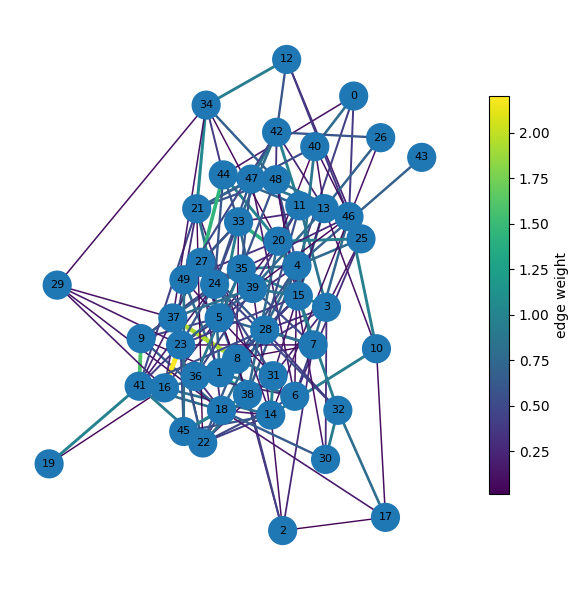

In [ ]:
# Simple visualization of the best partition
def visualize_graph(G, labels=None, title=None):
    """Show nodes colored by cluster labels and edges colored by their weight with a colorbar.

    - Nodes: colored by cluster (categorical colormap), with text labels.
    - Edges: colored by weight (continuous colormap), with colorbar.
    """
    pos = nx.spring_layout(G, seed=42)
    # Node colors by cluster labels (categorical colormap)
    node_cmap = plt.get_cmap('tab20')
    # Edge colors by weight (continuous colormap)
    edge_cmap = plt.get_cmap('viridis')

    # Gather edge weights
    weights = [d.get('weight', 1) for *_, d in G.edges(data=True)]
    w_min, w_max = (min(weights), max(weights)) if len(weights) else (0, 1)
    norm = Normalize(vmin=w_min, vmax=w_max if w_max > w_min else w_min + 1)
    edge_widths = [1.0 + 2.5 * norm(w) for w in weights] if len(weights) else 1.0

    fig, ax = plt.subplots(figsize=(6, 6))
    # Draw nodes with cluster colors
    if labels is None:
        labels = [0] * G.number_of_nodes()
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=labels, cmap=node_cmap, node_size=400)
    # Draw edges colored by weight
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=weights, edge_cmap=edge_cmap, edge_vmin=w_min, edge_vmax=w_max, width=edge_widths)
    # Node labels (names)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)

    # Colorbar for edges only
    sm = plt.cm.ScalarMappable(norm=norm, cmap=edge_cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.7, label='edge weight')

    if title:
        ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

visualize_graph(G)

## 3 - Clustering

### Method 1 - Louvain
#### In&Out
**Goal**: Detect **communities** in a graph by **maximizing modularity**.

**Inputs**
- A graph $G=(V,E)$ (weighted or unweighted).
- Optional parameters (as in `networkx.louvain_communities`):
  - `weight` (edge attribute)
  - `resolution` $\gamma$ (default 1)
  - `threshold`, `max_level`
  - `seed`

**Output**: A **list of sets**, each set = one community.

**Modularity**
For a partition $\{c_i\}$:

$$
Q = \frac{1}{2m} \sum_{i,j}
\left( A_{ij} - \gamma \frac{k_i k_j}{2m} \right)
\delta(c_i, c_j),
$$

where  
- $A_{ij}$: edge weight,  
- $k_i$: degree of node $i$,  
- $m = \tfrac12\sum_{ij}A_{ij}$.

#### How Louvain Works
**Iterate two phases**:

1. **Local move:**  
   Each node is moved to the neighboring community that yields the largest **modularity gain**  
   $$
   \Delta Q = \frac{1}{2m}\big(k_{i,C} - \gamma \frac{k_i\,\Sigma^{(C)}_{\text{tot}}}{2m}\big).
   $$

2. **Aggregation:**  
   Communities become super-nodes; edge weights between communities are summed.  
   Run phase 1 again on this compressed graph.

Stop when modularity no longer increases.

#### Minimal Example
```python
from networkx.algorithms.community import louvain_communities
import networkx as nx

G = nx.karate_club_graph()
communities = louvain_communities(G, resolution=1, seed=42)
print(communities)

Best resolution: 1.0, modularity=0.3607, communities=6
Robustness (ARI mean ± std at best resolution): 0.756 ± 0.143

Resolution  | Modularity(mean±std) | Avg #Communities
0.5        | 0.2616 ± 0.0015    | 2.00
0.8        | 0.3527 ± 0.0101    | 5.00
1.0        | 0.3589 ± 0.0011    | 5.60
1.2        | 0.3569 ± 0.0016    | 8.00
1.5        | 0.3471 ± 0.0052    | 10.00


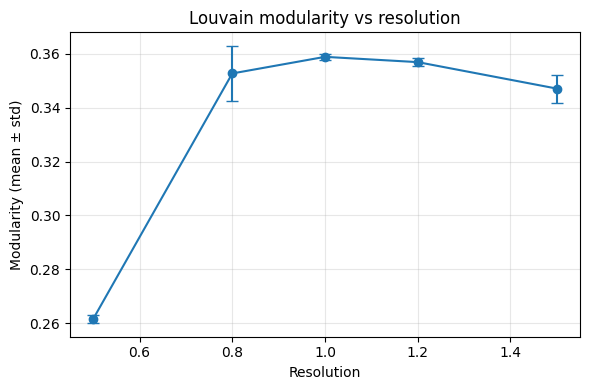

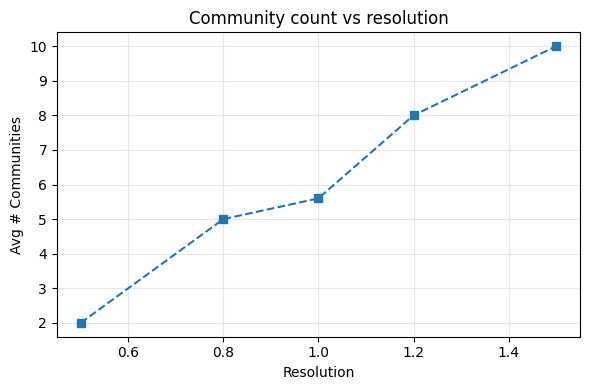

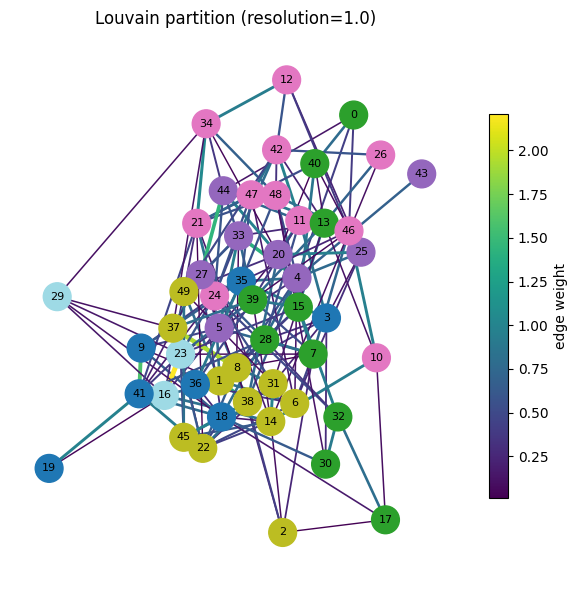

In [ ]:
plot_perf = 1

def communities_to_labels(communities, n_nodes):
    """Convert list of sets of nodes to a label array indexed by node id (assumes 0..n-1)."""
    labels = np.empty(n_nodes, dtype=int)
    for cid, comm in enumerate(communities):
        for node in comm:
            labels[node] = cid
    return labels

def run_louvain_resolution_scan(G, resolutions=(0.5, 0.8, 1.0, 1.2, 1.5), seeds=(0, 1, 2), weight='weight'):
    """Run Louvain for multiple resolutions and seeds; collect modularity statistics.

    Returns: list of dicts with keys: resolution, seed, modularity, n_comm, communities.
    """
    results = []
    for r in resolutions:
        for s in seeds:
            comms = louvain_communities(G, weight=weight, resolution=r, seed=s)
            mod = modularity(G, comms, weight=weight)
            results.append({'resolution': r, 'seed': s, 'modularity': mod, 'n_comm': len(comms), 'communities': comms})
    return results

def summarize_results(results):
    # Aggregate modularity per resolution
    summary = {}
    for r in sorted({d['resolution'] for d in results}):
        mods = [d['modularity'] for d in results if d['resolution'] == r]
        n_comms = [d['n_comm'] for d in results if d['resolution'] == r]
        summary[r] = {'mod_mean': np.mean(mods), 'mod_std': np.std(mods), 'n_comm_mean': np.mean(n_comms)}
    return summary

def choose_best_partition(results):
    # Pick partition with highest modularity; tie-breaker: fewer communities
    best = None
    for d in results:
        if best is None or d['modularity'] > best['modularity'] or (d['modularity'] == best['modularity'] and d['n_comm'] < best['n_comm']):
            best = d
    return best

def robustness_ari(results, resolution):
    # Compute ARI between all seed pairs at given resolution
    parts = [d for d in results if d['resolution'] == resolution]
    label_arrays = [communities_to_labels(p['communities'], G.number_of_nodes()) for p in parts]
    aris = []
    for (i, lab1), (j, lab2) in combinations(enumerate(label_arrays), 2):
        aris.append(adjusted_rand_score(lab1, lab2))
    return aris

# Ensure we use undirected graph for Louvain (directed version may be converted)
if Gd.is_directed():
    G_undirected_from_directed = Gd.to_undirected()
else:
    G_undirected_from_directed = Gd

resolutions = (0.5, 0.8, 1.0, 1.2, 1.5)
seeds = range(5)
results = run_louvain_resolution_scan(G, resolutions=resolutions, seeds=seeds)
summary = summarize_results(results)
best = choose_best_partition(results)
best_labels = communities_to_labels(best['communities'], G.number_of_nodes())
best_aris = robustness_ari(results, best['resolution'])

print(f"Best resolution: {best['resolution']}, modularity={best['modularity']:.4f}, communities={best['n_comm']}")
print(f"Robustness (ARI mean ± std at best resolution): {np.mean(best_aris):.3f} ± {np.std(best_aris):.3f}")

# Show summary table
print("\nResolution  | Modularity(mean±std) | Avg #Communities")
for r, vals in summary.items():
    print(f"{r:<10} | {vals['mod_mean']:.4f} ± {vals['mod_std']:.4f}    | {vals['n_comm_mean']:.2f}")

if plot_perf:
    # Plot modularity vs resolution
    plt.figure(figsize=(6,4))
    plt.errorbar([r for r in summary.keys()], [v['mod_mean'] for v in summary.values()], yerr=[v['mod_std'] for v in summary.values()], fmt='o-', capsize=4)
    plt.xlabel('Resolution')
    plt.ylabel('Modularity (mean ± std)')
    plt.title('Louvain modularity vs resolution')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot number of communities vs resolution
    plt.figure(figsize=(6,4))
    plt.plot([r for r in summary.keys()], [v['n_comm_mean'] for v in summary.values()], 's--')
    plt.xlabel('Resolution')
    plt.ylabel('Avg # Communities')
    plt.title('Community count vs resolution')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_graph(G, best_labels, title=f"Louvain partition (resolution={best['resolution']})")

### Method 2 - Girvan–Newman

The Girvan–Newman algorithm detects communities by iteratively removing the most “between” edges (bridges between groups).

Workflow

1. Compute edge betweenness centrality for every edge:
   
   $b_e = \sum_{s \ne t} \frac{\sigma_{st}(e)}{\sigma_{st}}$ where $\sigma_{st}$ is the number of shortest paths between $s$ and $t$, and $\sigma_{st}(e)$ is the number of those paths that go through edge $e$.
2. Remove the edge(s) with the highest betweenness.
3. Recompute betweenness on the new graph and repeat. This yields a hierarchy of partitions with an increasing number of communities.
4. Score each partition by modularity and select the best level:
   
   $$Q = \frac{1}{2m} \sum_{i,j} \Big(A_{ij} - \frac{k_i k_j}{2m}\Big) \, \delta(c_i, c_j)$$
   where $A_{ij}$ is the adjacency, $k_i$ is the degree of node $i$, $m$ is the total number of edges, and $\delta(c_i,c_j)=1$ if nodes $i$ and $j$ are in the same community.

Notes
- We evaluate partitions using NetworkX’s modularity and pick the maximum-$Q$ split (no need to predefine the number of clusters).
- Our visualization reuses the earlier function: nodes are colored by community, edges by weight with a colorbar.


GN best: Q=0.2162, communities=19


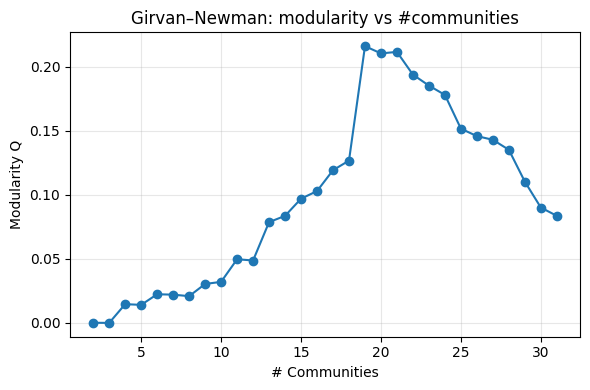

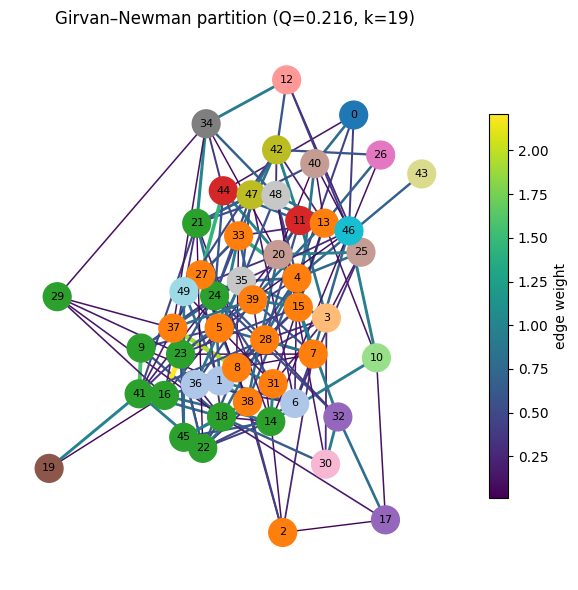

In [ ]:
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community import modularity as nx_modularity

def run_gn_select_by_modularity(G, max_levels=20, weight='weight'):
    """Run Girvan–Newman, compute modularity at each split, and pick the best partition.

    Args:
        G: undirected NetworkX graph.
        max_levels: limit number of splits (levels) to examine.
        weight: edge attribute name for weights (used in modularity scoring).
    Returns:
        dict with keys: 'best_partition', 'best_Q', 'history' (list of dicts per level).
    """
    # Ensure undirected for GN (if DiGraph given, convert)
    H = G.to_undirected() if G.is_directed() else G
    comp_gen = girvan_newman(H)
    history = []
    best = None
    for level, communities in enumerate(comp_gen, start=1):
        comms = tuple(sorted((set(c) for c in communities), key=lambda s: min(s)))
        Q = nx_modularity(H, comms, weight=weight)
        record = {'level': level, 'n_comm': len(comms), 'Q': Q, 'communities': comms}
        history.append(record)
        if best is None or Q > best['Q'] or (Q == best['Q'] and len(comms) < best['n_comm']):
            best = record
        if level >= max_levels or len(comms) >= H.number_of_nodes():
            break
    return {'best_partition': best['communities'], 'best_Q': best['Q'], 'history': history}

# Run GN on the same undirected, weighted graph as for Louvain (G)
gn_result = run_gn_select_by_modularity(G, max_levels=30, weight='weight')
gn_best = gn_result['best_partition']
gn_Q = gn_result['best_Q']
gn_hist = gn_result['history']
gn_best_labels = communities_to_labels(gn_best, G.number_of_nodes())
print(f"GN best: Q={gn_Q:.4f}, communities={len(gn_best)}")

# Plot GN modularity vs #communities (if desired)
if plot_perf:
    x = [h['n_comm'] for h in gn_hist]
    y = [h['Q'] for h in gn_hist]
    plt.figure(figsize=(6,4))
    plt.plot(x, y, 'o-')
    plt.xlabel('# Communities')
    plt.ylabel('Modularity Q')
    plt.title('Girvan–Newman: modularity vs #communities')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualize GN partition with the same plotting helper
visualize_graph(G, gn_best_labels, title=f"Girvan–Newman partition (Q={gn_Q:.3f}, k={len(gn_best)})")

### 3 - Model Comparison

### Comparison Output Explained
This table summarizes how similar the two community partitions (Louvain vs Girvan–Newman) are. Higher values mean closer agreement.

- Rand: fraction of node pairs on which the methods agree (same cluster or different clusters). Range [0, 1].
- Adjusted Rand (ARI): Rand index corrected for chance; 0 ≈ random, 1 = identical; can be negative if worse than random.
- Jaccard (pair-counting): among pairs co-assigned by at least one method, the fraction co-assigned by both. Range [0, 1].
- NMI: normalized mutual information between labelings; invariant to label permutations. 0 = independent, 1 = identical.

Below the table, the printed line shows how many communities each method found (useful context when interpreting the scores).

In [ ]:
# Compare Louvain vs Girvan–Newman partitions using clustering similarity metrics
from sklearn.metrics import rand_score, adjusted_rand_score, normalized_mutual_info_score

def jaccard_partition(y1, y2):
    """Pair-counting Jaccard similarity between two cluster labelings.
    Matches the definition used in exercise10 (counts co-assigned pairs)."""
    y1 = np.asarray(y1)
    y2 = np.asarray(y2)
    N = len(y1)
    S = 0  # pairs in same cluster in both
    D = 0  # pairs in different clusters in both
    for i in range(N):
        for j in range(i):
            same1 = (y1[i] == y1[j])
            same2 = (y2[i] == y2[j])
            if same1 and same2:
                S += 1
            if (not same1) and (not same2):
                D += 1
    total_pairs = N * (N - 1) / 2
    if total_pairs == D:
        return 0.0
    return S / (total_pairs - D)

# Ensure both label arrays exist and align in length
assert 'best_labels' in globals(), "Louvain labels 'best_labels' not found"
assert 'gn_best_labels' in globals(), "GN labels 'gn_best_labels' not found"
assert len(best_labels) == len(gn_best_labels), "Label arrays must have same length"

y_louvain = np.asarray(best_labels)
y_gn = np.asarray(gn_best_labels)

metrics = {
    'Rand': rand_score(y_louvain, y_gn),
    'Adjusted Rand (ARI)': adjusted_rand_score(y_louvain, y_gn),
    'Jaccard (pair-counting)': jaccard_partition(y_louvain, y_gn),
    'NMI': normalized_mutual_info_score(y_louvain, y_gn)
}
df_metrics = pd.DataFrame(metrics, index=['Louvain vs GN']).T
display(df_metrics)

# Optional: quick sanity display of community counts
print(f"Louvain communities: {len(np.unique(y_louvain))}, GN communities: {len(np.unique(y_gn))}")

,Louvain vs GN
Rand,0.768980
Adjusted Rand (ARI),0.087916
Jaccard (pair-counting),0.123839
NMI,0.477370


Louvain communities: 6, GN communities: 19


**OUTPUT:** different clusters (subsets of predictions) with insights.
for each cluster, generate the following outputs:
- most common words
- most common signs
- most common topics
- a .csv file, subset of *horoscope_full.csv* with all predictions in the cluster.